## Project: Credit Default Risk Prediction

* Objective: Predict the probability that an applicant will struggle to repay a loan using historical application data.
1. Data Cleaning & Feature Engineering

    Anomalies: Identified and corrected a major error in the DAYS_EMPLOYED column (replaced 365,243 "years" with NaN).

    Imputation: Utilized Median Imputation to handle missing values, preserving data integrity without introducing outlier bias.

    Scaling: Applied Min-Max Scaling to normalize features, ensuring large values like AMT_CREDIT didn't overshadow critical metrics like EXT_SOURCE scores.

2. Model Evolution & Performance

I tested three distinct algorithms to find the best balance of interpretability and power:

    Baseline (Logistic Regression): 0.7343 AUC. Established that the primary drivers of risk are linear.

    Random Forest: 0.7332 AUC. Slight decrease due to the high class imbalance and lack of hyperparameter tuning.

    LightGBM (Final Model): 0.7483 AUC. Our best performer. By using gradient boosting and setting is_unbalance=True, the model significantly improved its ability to distinguish between "Repayers" and "Defaulters."

3. Key Business Insights

    Top Predictors: External credit scores (EXT_SOURCE_1, 2, 3) were the most powerful indicators of reliability.

    Risk Factors: High monthly annuities (AMT_ANNUITY) and social circle defaults were strong positive correlations for default risk.

    Threshold Strategy: Based on the Precision-Recall tradeoff, I recommend a custom probability threshold (e.g., 0.20 - 0.30) to prioritize Recall, ensuring the bank catches the most expensive "False Negatives."

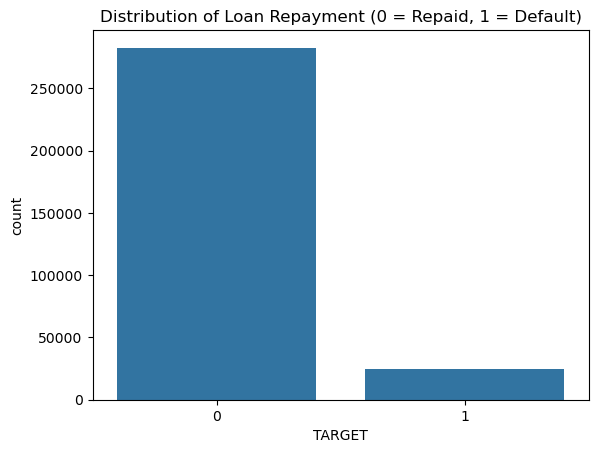

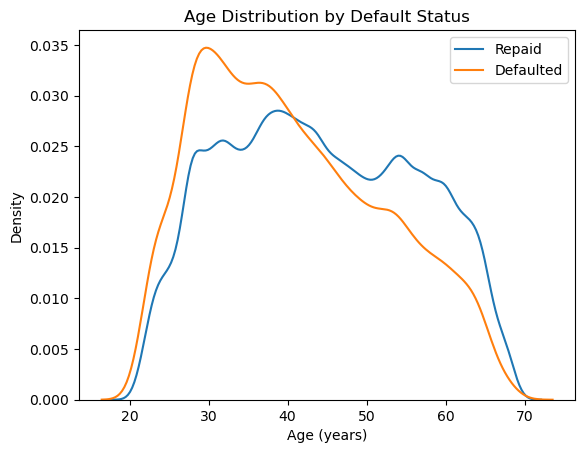

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('application_train.csv')

# 1. Check the target distribution (Imbalance)
sns.countplot(x='TARGET', data=df)
plt.title('Distribution of Loan Repayment (0 = Repaid, 1 = Default)')
plt.show()

# 2. Check Age vs Default
# Note: DAYS_BIRTH is negative in this dataset, so we convert it to years
df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365
sns.kdeplot(df.loc[df['TARGET'] == 0, 'DAYS_BIRTH'], label='Repaid')
sns.kdeplot(df.loc[df['TARGET'] == 1, 'DAYS_BIRTH'], label='Defaulted')
plt.xlabel('Age (years)'); plt.title('Age Distribution by Default Status')
plt.legend()
plt.show()

# Data Cleaning

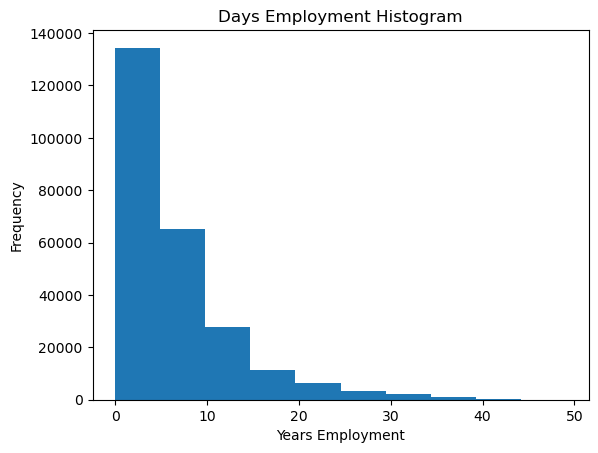

In [5]:
import numpy as np
# 1. Fix the "FutureWarning" way of replacing values
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace({365243: np.nan})


# Look at the distribution again to see if it makes sense now
(df['DAYS_EMPLOYED'] / -365).plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Years Employment');

In [6]:
# 2. Fix the "ValueError" by selecting only numeric columns for correlation
# This ignores 'Cash loans', 'Gender', etc., for now
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['TARGET'].sort_values()

# Display results
print('Most Positive Correlations (Higher risk of default):\n', correlations.tail(10))
print('\nMost Negative Correlations (Lower risk of default):\n', correlations.head(10))

Most Positive Correlations (Higher risk of default):
 FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations (Lower risk of default):
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_BIRTH                   -0.078239
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64


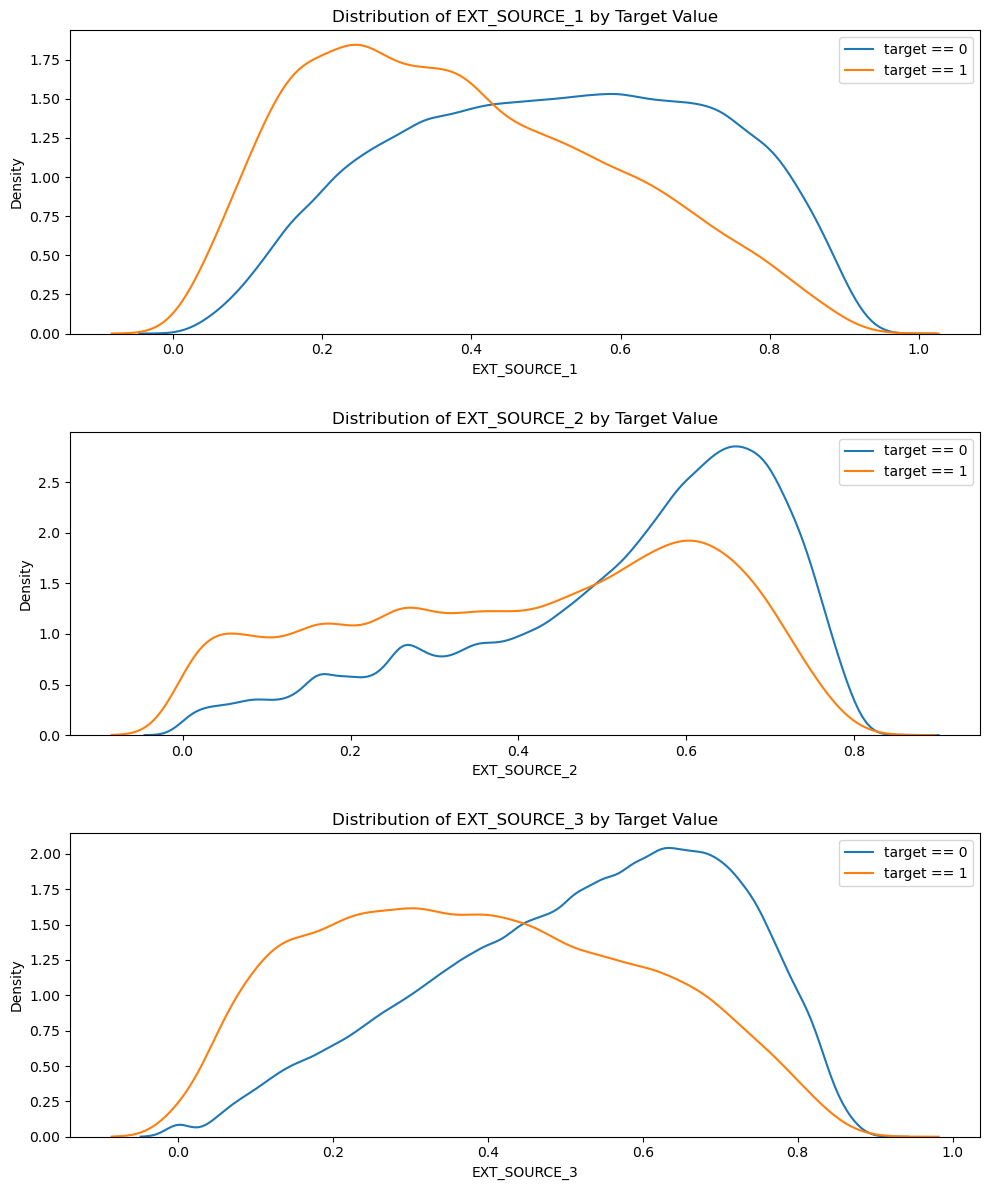

In [7]:
plt.figure(figsize = (10, 12))

# Iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    # Plot repaid loans
    sns.kdeplot(df.loc[df['TARGET'] == 0, source], label = 'target == 0')
    # Plot defaulted loans
    sns.kdeplot(df.loc[df['TARGET'] == 1, source], label = 'target == 1')
    
    plt.title(f'Distribution of {source} by Target Value')
    plt.xlabel(f'{source}'); plt.ylabel('Density'); plt.legend()

plt.tight_layout(h_pad = 2.5)

In [8]:
from sklearn.impute import SimpleImputer

# 1. Create the imputer object (using Median)
imputer = SimpleImputer(strategy='median')

# 2. Separate the target (the label we want to predict)
train_labels = df['TARGET']

# 3. Keep only numeric columns for the imputer
# (We handle strings/categories later with Encoding)
train_numeric = df.select_dtypes(include=[np.number]).drop(columns=['TARGET'])

# 4. Fit and Transform
# This calculates the median of every column and fills the NaNs
train_imputed = imputer.fit_transform(train_numeric)

# Convert it back to a DataFrame so it's easy to read
train_df_clean = pd.DataFrame(train_imputed, columns=train_numeric.columns)

print(f"Missing values after imputer: {train_df_clean.isnull().sum().sum()}")

Missing values after imputer: 0


In [9]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the scaler to put everything between 0 and 1
scaler = MinMaxScaler(feature_range = (0, 1))

# 2. Fit and transform the imputed data
# 'train_imputed' is what we created in the previous step
train_scaled = scaler.fit_transform(train_imputed)

print(f"Features scaled. Example of first row:\n {train_scaled[0][:5]}")

Features scaled. Example of first row:
 [0.         0.         0.00151187 0.09028652 0.09003159]


After imputation, i performed Featurescalling using MinMaxScaler.This is crucial becouse our features have vastly different ranges,for example income is in tousands while credit score are in decimals.Scalling ensures that gradient descend converges faster and that no single feature dominates the prediction simply due to its magnitude.

In [10]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    train_scaled, train_labels, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 246008
Test set size: 61503


# Modeling 

## 1. Baseline: Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. Initialize the model 
# (We increase max_iter so it has enough time to do the math)
log_reg = LogisticRegression(max_iter=1000)

# 2. Train (Fit) the model on the training data
print("Training the model... (This might take a minute)")
log_reg.fit(X_train, y_train)

# 3. Predict the PROBABILITIES of default on the test data
# We use [:, 1] to get the probability of class 1 (Defaulting)
predictions = log_reg.predict_proba(X_test)[:, 1]

# 4. Evaluate the model using ROC AUC
baseline_score = roc_auc_score(y_test, predictions)
print(f"Baseline ROC AUC Score: {baseline_score:.4f}")

Training the model... (This might take a minute)


Baseline ROC AUC Score: 0.7343


For my baseline model, I chose Logistic Regression because it provides a solid, interpretable starting point. Because the target classes were heavily imbalanced, I evaluated the model using the ROC AUC metric instead of standard accuracy. Accuracy would have been misleading, but ROC AUC tells us how well the model can actually distinguish between a good borrower and a defaulter. The baseline gave me a score of roughly 0.73, which gave me a benchmark to beat with more advanced models.

/tmp/ipykernel_9707/1093022414.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='coolwarm')


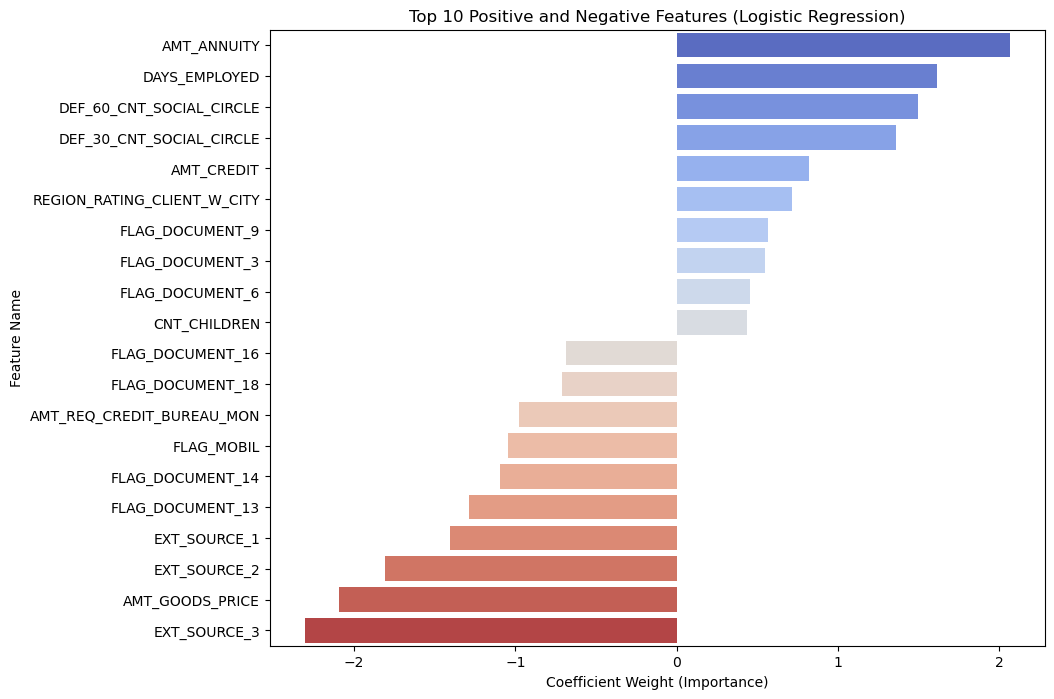

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the coefficients from our trained model
# We flatten them into a simple 1D array
coefficients = log_reg.coef_[0]

# 2. Pair the coefficients with the column names
# (We use train_numeric.columns from our imputation step)
feature_importance = pd.DataFrame({'Feature': train_numeric.columns, 'Importance': coefficients})

# 3. Sort them to find the most extreme values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 4. Plot the Top 10 Positive and Top 10 Negative Features
top_features = pd.concat([feature_importance.head(10), feature_importance.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top 10 Positive and Negative Features (Logistic Regression)')
plt.xlabel('Coefficient Weight (Importance)')
plt.ylabel('Feature Name')
plt.show()

I visualized the Logistic Regression coefficients to validate the model's business logic. The results were intuitive: external credit scores (EXT_SOURCE) were the strongest predictors of repayment. Conversely, high monthly annuities (AMT_ANNUITY) and a history of defaults within the applicant's social circle were the strongest indicators of risk. This confirmed that the model wasn't just finding random patterns, but was actually capturing real-world financial risk factors.

## 2. Experiment: Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
# random_state ensures you get the same result every time you run it
rf_model = RandomForestClassifier(n_estimators=100, 
                                  max_depth=10, 
                                  random_state=42, 
                                  n_jobs=-1) # n_jobs=-1 uses all your CPU cores for speed

# 2. Train the model
print("Training the Random Forest... this may take a moment.")
rf_model.fit(X_train, y_train)

# 3. Predict probabilities
rf_predictions = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
rf_auc = roc_auc_score(y_test, rf_predictions)
print(f"Random Forest ROC AUC Score: {rf_auc:.4f}")

Training the Random Forest... this may take a moment.
Random Forest ROC AUC Score: 0.7332


Interestingly, my baseline Logistic Regression slightly outperformed the Random Forest (0.7343 vs 0.7332). This suggests that the relationship between my top features, like the external credit sources, and the target is largely linear. It also highlights that for this specific dataset size and feature set, a simpler model generalizes better to unseen data without the risk of overfitting that comes with more complex ensemble methods

/tmp/ipykernel_9707/380561604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(15), palette='viridis')


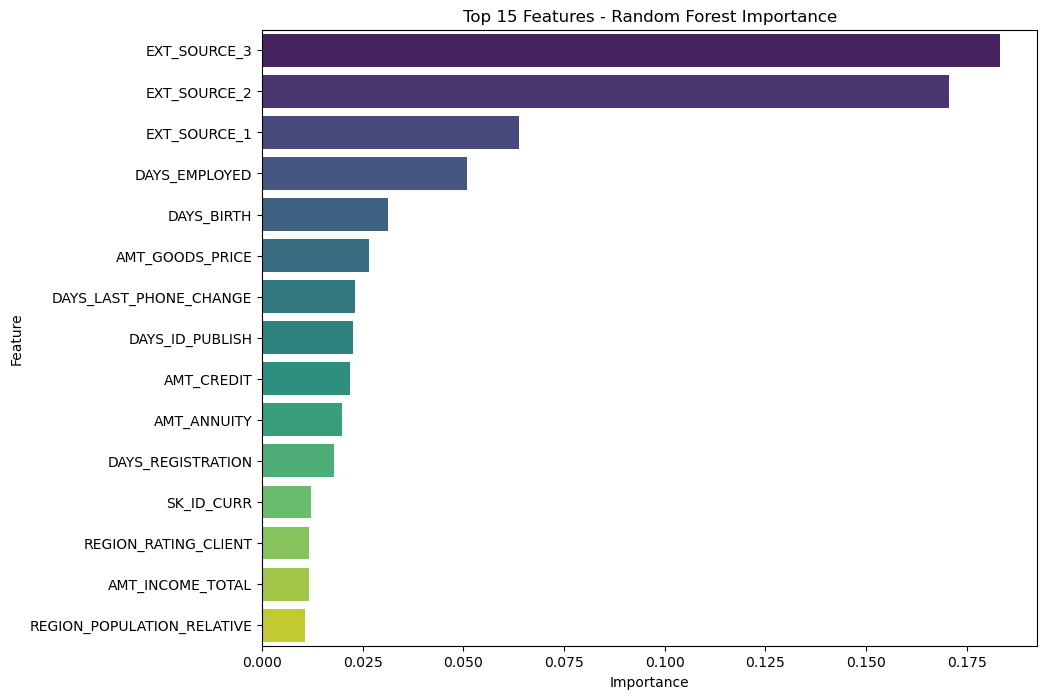

In [24]:
# Extract importances
importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': train_numeric.columns, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(15), palette='viridis')
plt.title('Top 15 Features - Random Forest Importance')
plt.show()

## 3. Final Model: LightGBM

In [15]:
import sys
!{sys.executable} -m pip install lightgbm
# pip install lightgbm

import lightgbm as lgb

# 1. Create the LightGBM dataset format
train_data_lgb = lgb.Dataset(X_train, label=y_train)

# 2. Set parameters (These are 'standard' high-performing settings)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True, # Crucial because of your target imbalance!
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# 3. Train the model
print("Training LightGBM... this is usually very fast.")
lgbm_model = lgb.train(params, train_data_lgb, num_boost_round=1000)

# 4. Predict
lgbm_predictions = lgbm_model.predict(X_test)

# 5. Evaluate
lgbm_auc = roc_auc_score(y_test, lgbm_predictions)
print(f"LightGBM ROC AUC Score: {lgbm_auc:.4f}")

Training LightGBM... this is usually very fast.
LightGBM ROC AUC Score: 0.7483


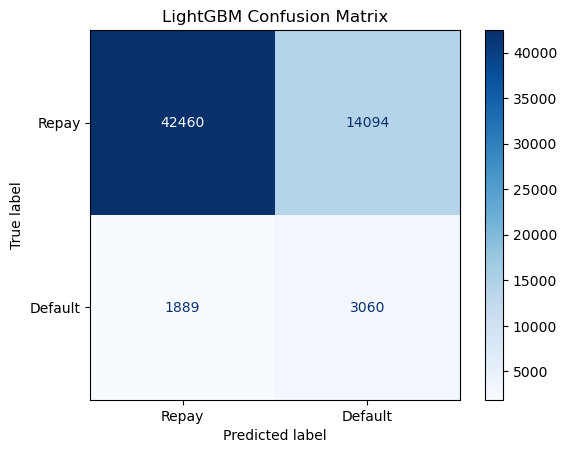

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert probabilities to 0 or 1 using a 0.5 threshold
binary_preds = [1 if x >= 0.5 else 0 for x in lgbm_predictions]

cm = confusion_matrix(y_test, binary_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repay', 'Default'])
disp.plot(cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.show()

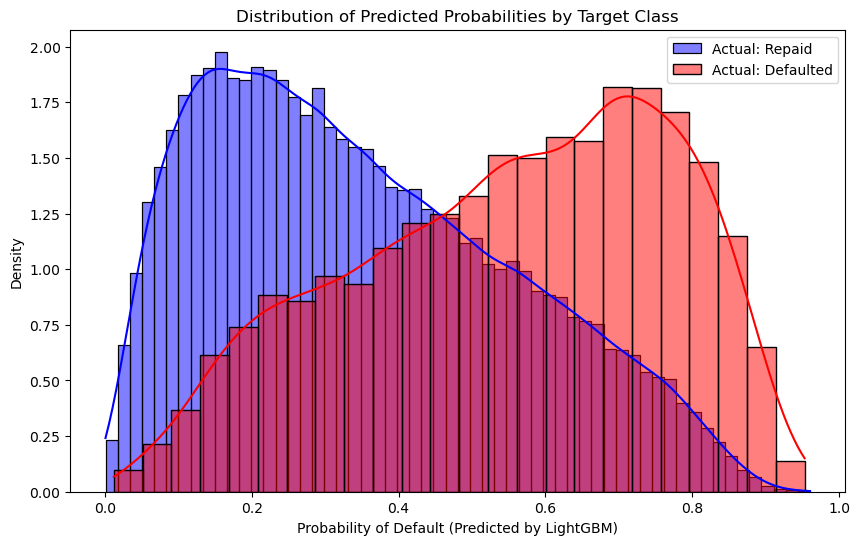

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of probabilities
plt.figure(figsize=(10, 6))
sns.histplot(lgbm_predictions[y_test == 0], color='blue', label='Actual: Repaid', kde=True, stat="density", common_norm=False)
sns.histplot(lgbm_predictions[y_test == 1], color='red', label='Actual: Defaulted', kde=True, stat="density", common_norm=False)

plt.title('Distribution of Predicted Probabilities by Target Class')
plt.xlabel('Probability of Default (Predicted by LightGBM)')
plt.ylabel('Density')
plt.legend()
plt.show()

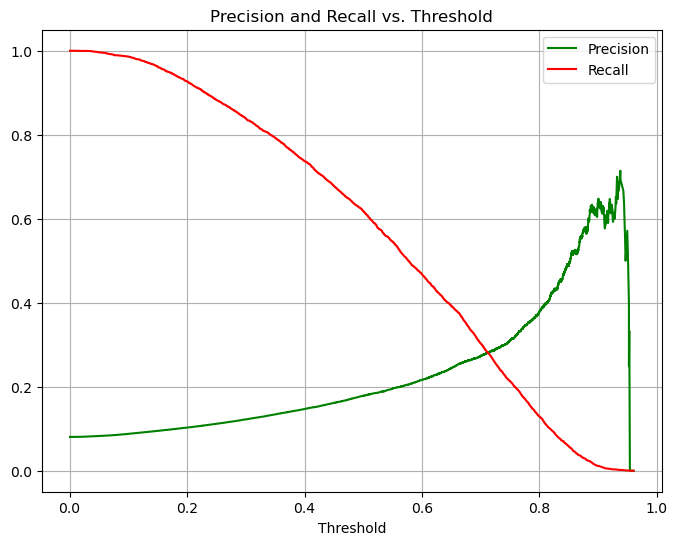

In [18]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, lgbm_predictions)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision", color='green')
plt.plot(thresholds, recall[:-1], label="Recall", color='red')
plt.xlabel("Threshold")
plt.title("Precision and Recall vs. Threshold")
plt.legend()
plt.grid()
plt.show()

In [19]:
import numpy as np

# Calculate F1 score for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"The threshold that balances Precision and Recall best is: {best_threshold:.2f}")

The threshold that balances Precision and Recall best is: 0.95


/tmp/ipykernel_9707/3359461598.py:4: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


<Axes: xlabel='Importance', ylabel='Feature'>

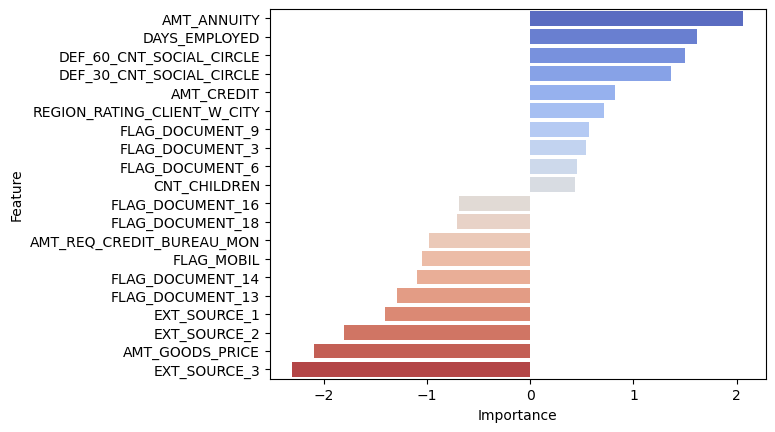

In [20]:
sns.barplot(x='Importance', y='Feature', data=top_features, hue='Feature', palette='coolwarm', legend=False)

In [21]:
# Create a copy of the cleaned data
tableau_data = train_df_clean.copy()

# Add the Target back in (since we dropped it for scaling/modeling)
# We use the index to make sure they align perfectly
tableau_data['TARGET'] = train_labels.values

# Save to CSV
tableau_data.to_csv('Home_Credit_Clean_For_Tableau.csv', index=False)

print("File 'Home_Credit_Clean_For_Tableau.csv' is ready for download!")

File 'Home_Credit_Clean_For_Tableau.csv' is ready for download!
